# 02 — Calidad de Datos: Instacart Online Grocery

**Proyecto:** Insight Commerce — Next-Basket Recommendation  
**Dataset:** Instacart Online Grocery Basket Analysis  
**Objetivo:** Diagnosticar los 5 riesgos de calidad y generar un reporte exportable.

| Sección | Riesgo |
|---------|--------|
| 0 | Configuración y carga |
| 1 | Estructura del dataset |
| 2 | 🔴 Desbalance de clases |
| 3 | 🔴 Alta cardinalidad de productos |
| 4 | 🔴 Sparsity de usuarios |
| 5 | 🔴 Data leakage temporal |
| 6 | 🔴 Sesgo hacia productos populares |
| 7 | Reporte consolidado y exportación |

---

## Sección 0 - Configuración y carga 

In [1]:
import os
import warnings
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#333333',
    'axes.grid': True, 'grid.color': '#eeeeee', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 9,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'lines.linewidth': 1.8, 'patch.linewidth': 0.5,
    # ── Fix texto ──────────────────────────────────
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#222222',
    'ytick.color': '#222222',
    'axes.titlecolor': '#222222',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
})

# ── Paleta de colores global ────────────────────────────────────────────────────
P = ['#bded7e','#fe495f',"#e5e377","#f30521",'#fe9d97','#d8fd94']

# ══════════════════════════════════════════════════════════
#  PARÁMETROS CONFIGURABLES — modificar según necesidad
# ══════════════════════════════════════════════════════════
DATA_PATH    = Path('../data/raw')         # carpeta con los CSVs de Instacart
OUTPUT_PATH  = Path('../reports')          # carpeta de reportes
FIG_DIR      = OUTPUT_PATH / 'figures'

MVP_MODE     = True        # True = muestra reducida | False = dataset completo
N_USUARIOS   = 50_000      # # usuarios a samplear si MVP_MODE = True
RANDOM_STATE = 42
MIN_COMPRAS  = 50          # mínimo de compras para tasas de recompra por producto

# ── Configuración de visualizaciones ───────────────────────
OUTPUT_PATH.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi']     = 100

print(f'Modo: {"MVP (" + str(N_USUARIOS) + " usuarios)" if MVP_MODE else "FULL (dataset completo)"}'  )
print(f'Output: {OUTPUT_PATH.resolve()}')

Modo: MVP (50000 usuarios)
Output: /Users/sofiaschanton/Desktop/Python3_Henry/Proyecto Final/insight-commerce-recsys/reports


### Carga de datos

Las tablas de dimensiones (`products`, `aisles`, `departments`) se cargan completas.
Para las tablas de hechos se realiza un muestreo estratificado por usuario para
mantener la coherencia: todas las órdenes de un usuario muestreado se incluyen.

In [2]:
# ── Tablas de dimensiones: carga completa ──────────────────
products    = pd.read_csv(os.path.join(DATA_PATH, 'products.csv'))
aisles      = pd.read_csv(os.path.join(DATA_PATH, 'aisles.csv'))
departments = pd.read_csv(os.path.join(DATA_PATH, 'departments.csv'))

# ── Optimización de dtypes en dimensiones ──────────────────
products['product_id']   = products['product_id'].astype('int64')
products['aisle_id']     = products['aisle_id'].astype('int64')
products['department_id']= products['department_id'].astype('int64')
aisles['aisle_id']       = aisles['aisle_id'].astype('int64')
departments['department_id'] = departments['department_id'].astype('int64')

# ── Orders: muestreo por usuario ───────────────────────────
orders_full = pd.read_csv(os.path.join(DATA_PATH, 'orders.csv'),
                          dtype={'order_id': 'int64', 'user_id': 'int64',
                                 'order_number': 'int64', 'order_dow': 'int64',
                                 'order_hour_of_day': 'int64'})

if N_USUARIOS is not None:
    usuarios_muestra = (orders_full['user_id']
                        .drop_duplicates()
                        .sample(n=N_USUARIOS, random_state=RANDOM_STATE))
    orders = orders_full[orders_full['user_id'].isin(usuarios_muestra)].copy()
else:
    orders = orders_full.copy()

order_ids_muestra = set(orders['order_id'].unique())

# ── Tablas de hechos: filtrar por órdenes de la muestra ────
order_products_prior = pd.read_csv(
    os.path.join(DATA_PATH, 'order_products__prior.csv'),
    dtype={'order_id': 'int64', 'product_id': 'int64',
           'add_to_cart_order': 'int64', 'reordered': 'int64'})
order_products_prior = order_products_prior[
    order_products_prior['order_id'].isin(order_ids_muestra)].copy()

order_products_train = pd.read_csv(
    os.path.join(DATA_PATH, 'order_products__train.csv'),
    dtype={'order_id': 'int64', 'product_id': 'int64',
           'add_to_cart_order': 'int64', 'reordered': 'int64'})
order_products_train = order_products_train[
    order_products_train['order_id'].isin(order_ids_muestra)].copy()

# ── Tablas de dimensiones enriquecidas ────────────────────
products_full = (products
                 .merge(aisles, on='aisle_id')
                 .merge(departments, on='department_id'))


# ── Join consolidado: tabla de hechos enriquecida ──────────
# Se usa para análisis de productos, categorías y recompra (sección 2 y 5).
# NO incluye order_products_train para evitar data leakage.
df = (order_products_prior
      .merge(orders[['order_id', 'user_id', 'order_number',
                      'order_dow', 'order_hour_of_day',
                      'days_since_prior_order']], on='order_id')
      .merge(products[['product_id', 'product_name', 'aisle_id', 'department_id']], on='product_id')
      .merge(departments[['department_id', 'department']], on='department_id')
      .merge(aisles[['aisle_id', 'aisle']], on='aisle_id'))

# ── Métricas pre-calculadas reutilizables ────────────────────────────────────
ordenes_por_usuario = orders.groupby('user_id')['order_id'].count()

# ── Acumulador del reporte de calidad ─────────────────────
quality_report = {}

print("✓ Carga y join exitosos")
print(f"  Usuarios en muestra:            {orders['user_id'].nunique():>10,}")
print(f"  Órdenes en muestra:             {orders['order_id'].nunique():>10,}")
print(f"  Registros order_products_prior: {len(order_products_prior):>10,}")
print(f"  Registros order_products_train: {len(order_products_train):>10,}")
print(f"  Registros en df consolidado:    {len(df):>10,}")
print(f"  Productos (catálogo completo):  {len(products):>10,}")
print(f"  Memoria df consolidado:         {df.memory_usage(deep=True).sum() / 1e6:>9.1f} MB")

✓ Carga y join exitosos
  Usuarios en muestra:                50,000
  Órdenes en muestra:                831,128
  Registros order_products_prior:  7,927,707
  Registros order_products_train:    335,968
  Registros en df consolidado:     7,927,707
  Productos (catálogo completo):      49,688
  Memoria df consolidado:            2240.3 MB


---
## Sección 1 - Estructura del dataset
Antes de realizar cualquier análisis es necesario examinar la estructura del dataset para comprender sus características básicas. En esta etapa se revisa el número de registros por tabla, los tipos de datos de cada variable y la presencia de valores faltantes.

Esta exploración inicial permite evaluar la calidad de los datos y establecer criterios adecuados para su limpieza, transformación y posterior análisis

In [3]:
# ── Estructura de los datos ───────────────────────────

for nombre, tabla in [('orders', orders),
                      ('order_products_prior', order_products_prior),
                      ('order_products_train', order_products_train),
                      ('products', products),
                      ('aisles', aisles),
                      ('departments', departments)]:
    print(f"\n{'='*45}")
    print(f"  Tabla: {nombre}")
    print(f"  Filas: {tabla.shape[0]:,}  |  Columnas: {tabla.shape[1]}")
    nulos = tabla.isnull().sum()
    nulos = nulos[nulos > 0]
    print(f"  Nulos:\n{nulos}" if len(nulos) > 0 else "  Nulos: ninguno")
    print(tabla.dtypes.to_string())

print(f"\n{'='*45}")
print(f"Resumen general")
print(f"  Usuarios únicos:   {orders['user_id'].nunique():,}")
print(f"  Órdenes únicas:    {orders['order_id'].nunique():,}")
print(f"  Productos únicos:  {products['product_id'].nunique():,}")
print(f"  Departamentos:     {departments['department_id'].nunique()}")
print(f"  Pasillos:          {aisles['aisle_id'].nunique()}")

# Verificación de duplicados
dup_prior = order_products_prior.duplicated(subset=['order_id', 'product_id']).sum()
dup_train = order_products_train.duplicated(subset=['order_id', 'product_id']).sum()
print(f"\nDuplicados (order_id, product_id):")
print(f"  order_products_prior: {dup_prior:,}")
print(f"  order_products_train: {dup_train:,}")


  Tabla: orders
  Filas: 831,128  |  Columnas: 7
  Nulos:
days_since_prior_order    50000
dtype: int64
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64

  Tabla: order_products_prior
  Filas: 7,927,707  |  Columnas: 4
  Nulos: ninguno
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64

  Tabla: order_products_train
  Filas: 335,968  |  Columnas: 4
  Nulos: ninguno
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64

  Tabla: products
  Filas: 49,688  |  Columnas: 4
  Nulos: ninguno
product_id        int64
product_name     object
aisle_id          int64
department_id     int64

  Tabla: aisles
  Filas: 134  |  Columnas: 2
  Nulos: ninguno
aisle_id     int64
aisle       object

  Tabla: dep

### **Hallazgos**

La muestra cargada representa 50.000 usuarios con 831.128 órdenes y 7.927.707 registros en el historial de compras (order_products_prior). El catálogo de productos es completo con 49.688 productos distribuidos en 21 departamentos y 134 pasillos.

- #### *Observación sobre nulos*
`days_since_prior_order` tiene exactamente un nulo por usuario — su primera orden, que por definición no tiene orden anterior. Es un **nulo estructural esperado**, no un problema de calidad.

- #### *Columna `eval_set`*
Clasifica cada orden en `prior` (historial), `train` (target del modelo) o `test` (evaluación Kaggle sin ground truth). Esta columna es metadata de la competencia — no es una variable de negocio y no se usará como feature.

## Sección 2 — 🔴 Riesgo 1: Desbalance de clases

El desbalance de clases es un aspecto crítico a considerar en este problema.
En tareas de recomendación, la mayoría de los pares usuario-producto
corresponden a casos donde el usuario no vuelve a comprar el producto,
mientras que los casos de recompra suelen ser menos frecuentes.

**Variable analizada:** `reordered` en `order_products_prior`

> ⚠️ **Nota importante para el modelado:** la columna `reordered` en
> `order_products_prior` indica si ese producto fue reordenado respecto
> a la orden inmediatamente anterior — es una aproximación al target
> real pero no es idéntica a él.
>
> Como el **target del modelo** es si el usuario compró ese producto
> en su **última orden** (`order_products_train`). El desbalance
> calculado aquí puede diferir levemente del desbalance que se
> observará al construir el feature matrix con el split temporal
> correcto (prior → train).
>
> Se recomienda que DS-3 recalcule el ratio de desbalance sobre el
> feature matrix final antes de decidir la estrategia de manejo
> (`class_weight`, `scale_pos_weight` o submuestreo).

Distribución de la variable target (reordered):
  Clase 0 (no reordenado):  3,249,449  (40.99%)
  Clase 1 (reordenado)   :  4,678,258  (59.01%)
  Ratio 0:1              : 0.69:1
  Severidad: BAJA
  ✅ Desbalance manejable


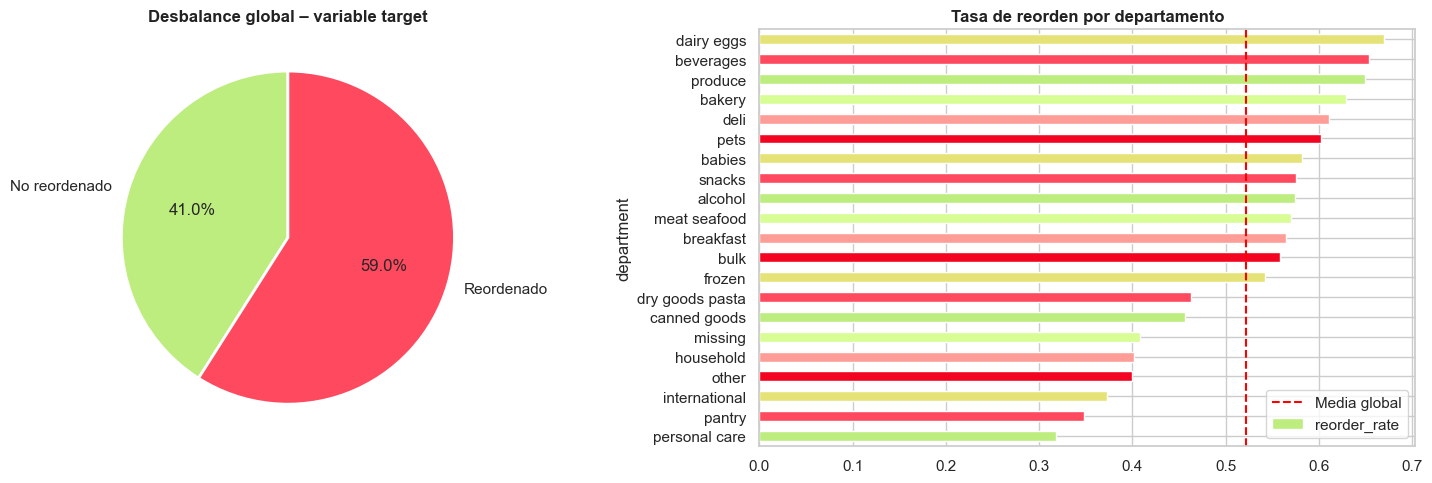

In [ ]:
vc     = order_products_prior['reordered'].value_counts().sort_index()
vc_pct = order_products_prior['reordered'].value_counts(normalize=True).sort_index()
ratio  = vc[0] / vc[1]

print('Distribución de la variable reordered:')
print(f'  Clase 0 (no reordenado): {vc[0]:>10,}  ({vc_pct[0]:.2%})')
print(f'  Clase 1 (reordenado)   : {vc[1]:>10,}  ({vc_pct[1]:.2%})')
print(f'  Ratio 0:1              : {ratio:.2f}:1')
severity = 'ALTA' if ratio > 3 else 'MEDIA' if ratio > 1.5 else 'BAJA'
print(f'  Severidad: {severity}')
if ratio > 3:
    print('  ⚠️  Desbalance significativo → usar class_weight en LightGBM')
else:
    print('  ✅ Desbalance manejable')

# Desbalance por departamento
dept_reorder = (order_products_prior
                .merge(products_full[['product_id', 'department']], on='product_id')
                .groupby('department')['reordered']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'reorder_rate', 'count': 'n'})
                .sort_values('reorder_rate'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].pie(vc_pct.values, labels=['No reordenado', 'Reordenado'],
            colors=P, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Desbalance global – variable target', fontweight='bold')

dept_reorder['reorder_rate'].plot(kind='barh', ax=axes[1], color=P, edgecolor='white')
axes[1].axvline(x=dept_reorder['reorder_rate'].mean(), color='red', linestyle='--', label='Media global')
axes[1].set_title('Tasa de reorden por departamento', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'q1_desbalance_clases.png', bbox_inches='tight')
plt.show()

quality_report['desbalance_clases'] = {
    'clase_0_count': int(vc[0]), 'clase_0_pct': round(float(vc_pct[0]), 4),
    'clase_1_count': int(vc[1]), 'clase_1_pct': round(float(vc_pct[1]), 4),
    'ratio_0_1': round(float(ratio), 2),
    'severidad': severity
}

### **Hallazgos**

La estrategia recomendada es
usar `class_weight='balanced'` en LightGBM o `scale_pos_weight` en XGBoost.

---
## Sección 3 — 🔴 Riesgo 2: Alta cardinalidad de productos

Con alrededor de 50K productos en el catálogo, las compras siguen una distribución tipo Pareto: un pequeño grupo de productos concentra la mayoría de las compras, mientras que la gran mayoría pertenece a la long tail.


Productos únicos en el catálogo   : 49,688
Productos con al menos 1 compra   : 46,904
Productos nunca comprados         : 2,784

Long tail:
  ≤   1 compras: 3,522 productos (7.51%)
  ≤   5 compras: 13,151 productos (28.04%)
  ≤  10 compras: 19,271 productos (41.09%)
  ≤  50 compras: 32,794 productos (69.92%)
  ≤ 100 compras: 37,442 productos (79.83%)


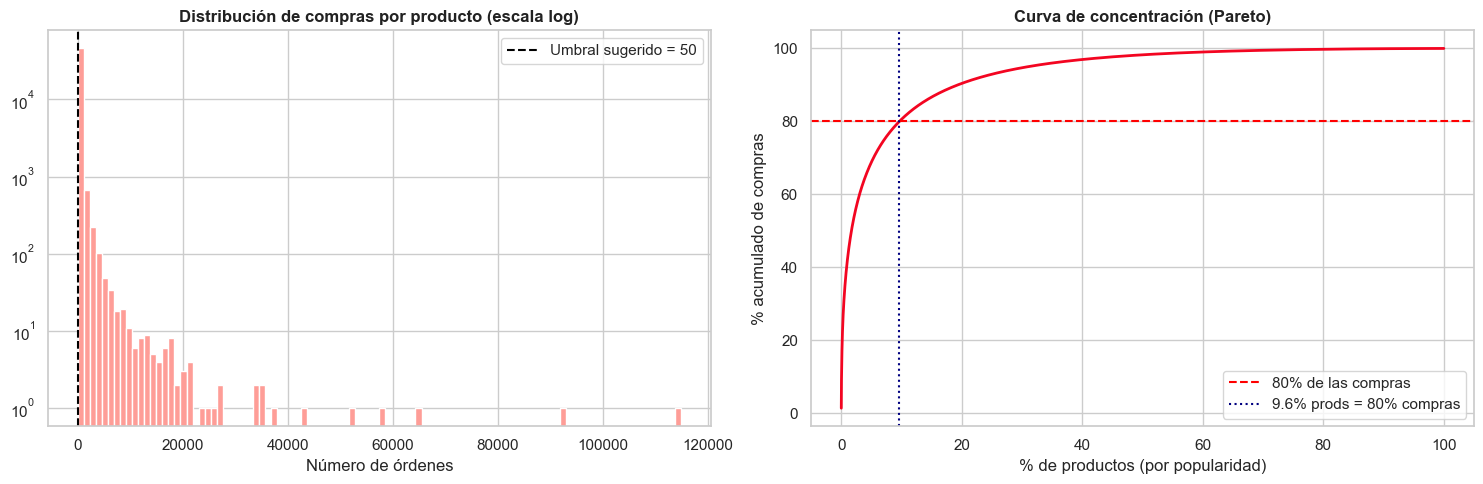

→ El 9.6% de los productos concentra el 80% de las compras (Pareto)


In [12]:
n_products_total    = products['product_id'].nunique()
n_products_in_prior = order_products_prior['product_id'].nunique()
products_never_bought = n_products_total - n_products_in_prior

prod_freq = order_products_prior.groupby('product_id')['order_id'].count().reset_index(name='n_orders')

thresholds = [1, 5, 10, 50, 100]
long_tail = {}
print(f'Productos únicos en el catálogo   : {n_products_total:,}')
print(f'Productos con al menos 1 compra   : {n_products_in_prior:,}')
print(f'Productos nunca comprados         : {products_never_bought:,}')
print('\nLong tail:')
for t in thresholds:
    n = (prod_freq['n_orders'] <= t).sum()
    pct = round(n / n_products_in_prior * 100, 2)
    long_tail[f'lte_{t}'] = {'count': int(n), 'pct': pct}
    print(f'  ≤ {t:3d} compras: {n:,} productos ({pct}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(prod_freq['n_orders'], bins=100, color='#fe9d97', edgecolor='white', log=True)
axes[0].axvline(x=50, color='black', linestyle='--', label='Umbral sugerido = 50')
axes[0].set_title('Distribución de compras por producto (escala log)', fontweight='bold')
axes[0].set_xlabel('Número de órdenes')
axes[0].legend()

sorted_freq = np.sort(prod_freq['n_orders'].values)[::-1]
cum_pct  = np.cumsum(sorted_freq) / sorted_freq.sum() * 100
prod_pct = np.arange(1, len(sorted_freq)+1) / len(sorted_freq) * 100
axes[1].plot(prod_pct, cum_pct, color='#f30521', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='80% de las compras')
idx_80 = np.searchsorted(cum_pct, 80)
pct_80 = prod_pct[idx_80]
axes[1].axvline(x=pct_80, color='navy', linestyle=':', label=f'{pct_80:.1f}% prods = 80% compras')
axes[1].set_title('Curva de concentración (Pareto)', fontweight='bold')
axes[1].set_xlabel('% de productos (por popularidad)')
axes[1].set_ylabel('% acumulado de compras')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_alta_cardinalidad.png', bbox_inches='tight')
plt.show()
print(f'→ El {pct_80:.1f}% de los productos concentra el 80% de las compras (Pareto)')

quality_report['alta_cardinalidad'] = {
    'n_productos_total': n_products_total,
    'n_productos_comprados': n_products_in_prior,
    'productos_nunca_comprados': int(products_never_bought),
    'long_tail': long_tail,
    'pareto_80_pct_productos': round(pct_80, 2)
}

## Sección 4 — 🔴 Riesgo 3: Sparsity de usuarios

Esta sección analiza la sparsity de los usuarios — aquellos con poco
historial de compras en el conjunto **prior** (historial de entrenamiento).

> **Criterio de filtro:** se usa exclusivamente `eval_set == 'prior'`
> para medir el historial disponible por usuario. Esto es consistente
> con el split temporal del modelo: lo que el modelo "ve" de cada
> usuario son sus órdenes prior, no la orden de evaluación.
> El acumulador `ordenes_por_usuario` de la Sección 0 incluye todas
> las órdenes y **no debe usarse** para este análisis de sparsity.

Los usuarios con menos de 5 órdenes prior tienen información limitada
y pueden requerir recomendaciones basadas en popularidad global
como estrategia de fallback.

Total de usuarios: 50,000
Órdenes — media: 15.6 | mediana: 9 | máx: 99

Usuarios sparse por umbral:
  🟢 < 3 órdenes: 0 (0.0%)
  🔴 < 5 órdenes: 10,573 (21.1%)
  🔴 < 10 órdenes: 25,319 (50.6%)

Sparsity media de la matriz usuario-producto: 99.8692%


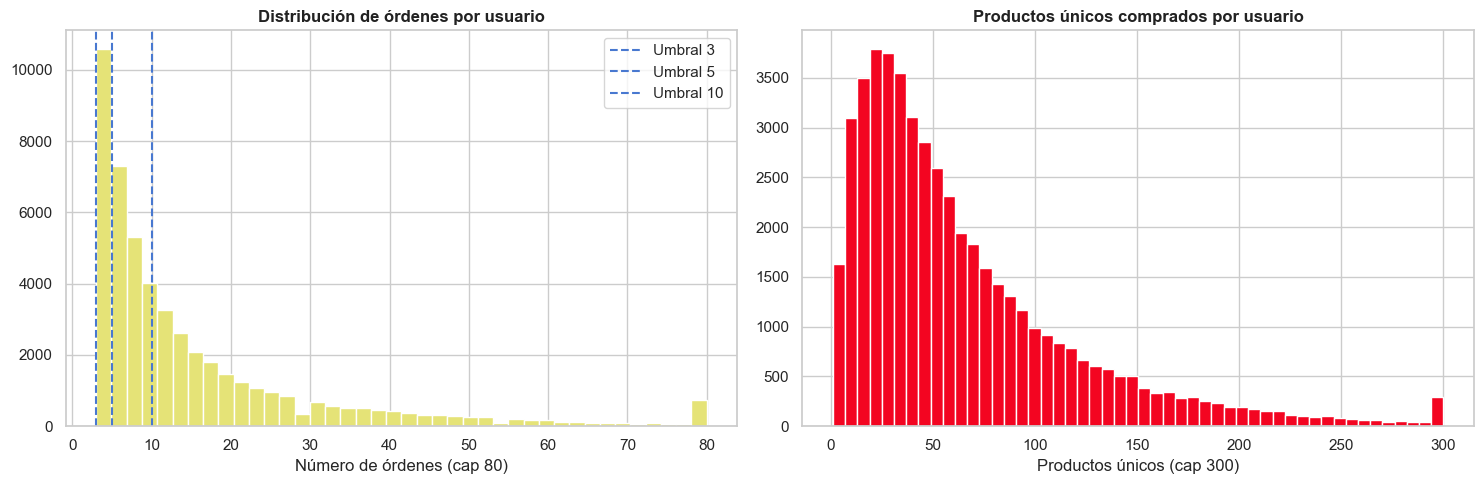

In [6]:
# Se filtra eval_set == 'prior' para contar solo órdenes del historial, excluyendo la orden de evaluación (train/test).
# Nota: ordenes_por_usuario calculado en Sección 0 incluye todas las órdenes (prior + train + test) — usar user_stats para análisis de
# sparsity para mantener consistencia con el split temporal del modelo.
user_stats = (orders[orders['eval_set'] == 'prior']
              .groupby('user_id')
              .agg(n_orders=('order_id', 'count'),
                   max_order_number=('order_number', 'max'))
              .reset_index())

sparse_thresholds = [3, 5, 10]
sparse_results = {}
total_users = len(user_stats)

print(f'Total de usuarios: {total_users:,}')
print(f'Órdenes — media: {user_stats["n_orders"].mean():.1f} | mediana: {user_stats["n_orders"].median():.0f} | máx: {user_stats["n_orders"].max()}')
print('\nUsuarios sparse por umbral:')
for t in sparse_thresholds:
    n   = (user_stats['n_orders'] < t).sum()
    pct = n / total_users
    sparse_results[f'lt_{t}'] = {'count': int(n), 'pct': round(pct, 4)}
    sev = '🔴' if pct > 0.2 else '🟡' if pct > 0.1 else '🟢'
    print(f'  {sev} < {t} órdenes: {n:,} ({pct:.1%})')

user_product_counts = (order_products_prior
                       .merge(orders[['order_id', 'user_id']], on='order_id')
                       .groupby('user_id')['product_id'].nunique()
                       .reset_index(name='n_unique_products'))
total_products = products['product_id'].nunique()
user_product_counts['sparsity'] = 1 - (user_product_counts['n_unique_products'] / total_products)

sparsity_media = user_product_counts['sparsity'].mean()
print(f'\nSparsity media de la matriz usuario-producto: {sparsity_media:.4%}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
user_stats['n_orders'].clip(upper=80).hist(bins=40, ax=axes[0], color='#e5e377', edgecolor='white')
for t in sparse_thresholds:
    axes[0].axvline(x=t, linestyle='--', label=f'Umbral {t}')
axes[0].set_title('Distribución de órdenes por usuario', fontweight='bold')
axes[0].set_xlabel('Número de órdenes (cap 80)')
axes[0].legend()

user_product_counts['n_unique_products'].clip(upper=300).hist(bins=50, ax=axes[1], color='#f30521', edgecolor='white')
axes[1].set_title('Productos únicos comprados por usuario', fontweight='bold')
axes[1].set_xlabel('Productos únicos (cap 300)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_alta_cardinalidad.png', bbox_inches='tight')
plt.show()

quality_report['sparsity_usuarios'] = {
    'total_usuarios': total_users,
    'media_ordenes': round(float(user_stats['n_orders'].mean()), 2),
    'mediana_ordenes': float(user_stats['n_orders'].median()),
    'sparsity_media_matriz': round(float(sparsity_media), 6),
    'sparse_por_umbral': sparse_results
}

---
## Sección 5 — 🔴 Riesgo 4: Data leakage temporal

Esta sección verifica que los datos respeten el orden temporal para evitar data leakage.

- prior representa el historial del usuario (entrada del modelo).

- train corresponde a la última orden del usuario (target).

Los order_id de prior y train no deben solaparse. Si esto ocurre, habría leakage, lo que podría hacer que el modelo aprenda información del futuro y genere overfitting.

Verificaciones de leakage temporal:
  ✅  usuarios_con_multiples_eval: 0
  ✅  eval_no_es_ultima_orden: 0
  ✅  overlap_order_ids_prior_train: 0


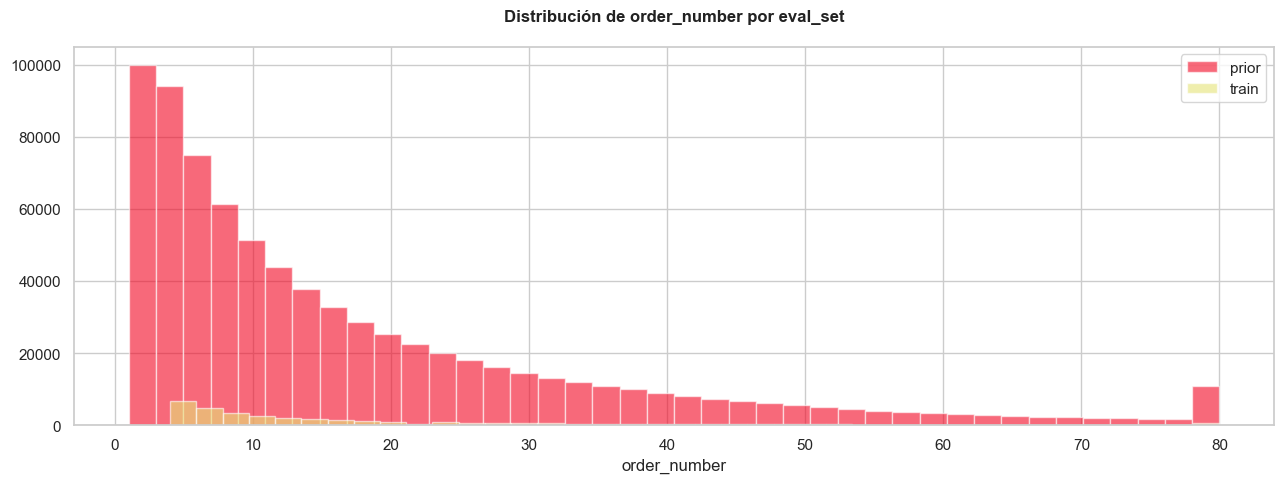

In [7]:
leakage_checks = {}

# 1. Cada usuario tiene exactamente 1 orden en train o test
train_test_per_user = (orders[orders['eval_set'].isin(['train', 'test'])]
                       .groupby('user_id')['order_id'].count())
leakage_checks['usuarios_con_multiples_eval'] = int((train_test_per_user > 1).sum())

# 2. La orden de eval debe ser la última (mayor order_number) del usuario
max_order_n  = orders.groupby('user_id')['order_number'].max().reset_index(name='max_n')
eval_order_n = (orders[orders['eval_set'].isin(['train', 'test'])]
                [['user_id', 'order_number']]
                .rename(columns={'order_number': 'eval_n'}))
check_df = max_order_n.merge(eval_order_n, on='user_id')
leakage_checks['eval_no_es_ultima_orden'] = int((check_df['eval_n'] != check_df['max_n']).sum())

# 3. No hay overlap de order_ids entre prior y train
prior_ids = set(orders[orders['eval_set'] == 'prior']['order_id'])
train_ids  = set(orders[orders['eval_set'] == 'train']['order_id'])
leakage_checks['overlap_order_ids_prior_train'] = len(prior_ids & train_ids)

print('Verificaciones de leakage temporal:')
for k, v in leakage_checks.items():
    status = '✅' if v == 0 else '🔴 LEAKAGE DETECTADO'
    print(f'  {status}  {k}: {v}')

resultado = 'OK' if all(v == 0 for v in leakage_checks.values()) else 'PROBLEMA DETECTADO'
quality_report['leakage_temporal'] = {**leakage_checks, 'resultado_global': resultado}

# Visualización de distribución de order_number por eval_set
fig, ax = plt.subplots(figsize=(13, 5))
for eval_set, color in [('prior', '#f30521'), ('train', '#e5e377')]:
    subset = orders[orders['eval_set'] == eval_set]['order_number']
    if len(subset) > 0:
        subset.clip(upper=80).hist(bins=40, ax=ax, alpha=0.6, label=eval_set, color=color, edgecolor='white')
ax.set_title('Distribución de order_number por eval_set\n', fontweight='bold')
ax.set_xlabel('order_number')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'q4_leakage_temporal.png', bbox_inches='tight')
plt.show()

## Sección 6 — 🔴 Riesgo 5: Sesgo hacia productos populares

Esta sección cuantifica la concentración de compras en un pequeño grupo
de productos y evalúa si la popularidad global es un buen predictor
de recompra.

### ¿Por qué es un riesgo?

Si un porcentaje pequeño de productos concentra la mayoría de las
compras, un modelo basado únicamente en popularidad global puede
tener métricas engañosamente altas — no porque sea inteligente,
sino porque recomienda siempre los mismos productos masivos.

### Distribución de popularidad (Pareto)

Un pequeño porcentaje de productos concentra el 80% de las compras.
Esto tiene dos implicancias:
- El baseline de popularidad global va a tener buenas métricas brutas
  pero pobre personalización
- DS-2 debe incluir features relativas al usuario para capturar
  preferencias individuales más allá de la popularidad global

Concentración de popularidad:
  Percentil 50:       17 órdenes
  Percentil 75:       71 órdenes
  Percentil 90:      271 órdenes
  Percentil 95:      599 órdenes
  Percentil 99:    2,499 órdenes

Top 1% de productos (470) concentra el 41.9% de las compras
Correlación popularidad ↔ tasa de reorden: 0.146


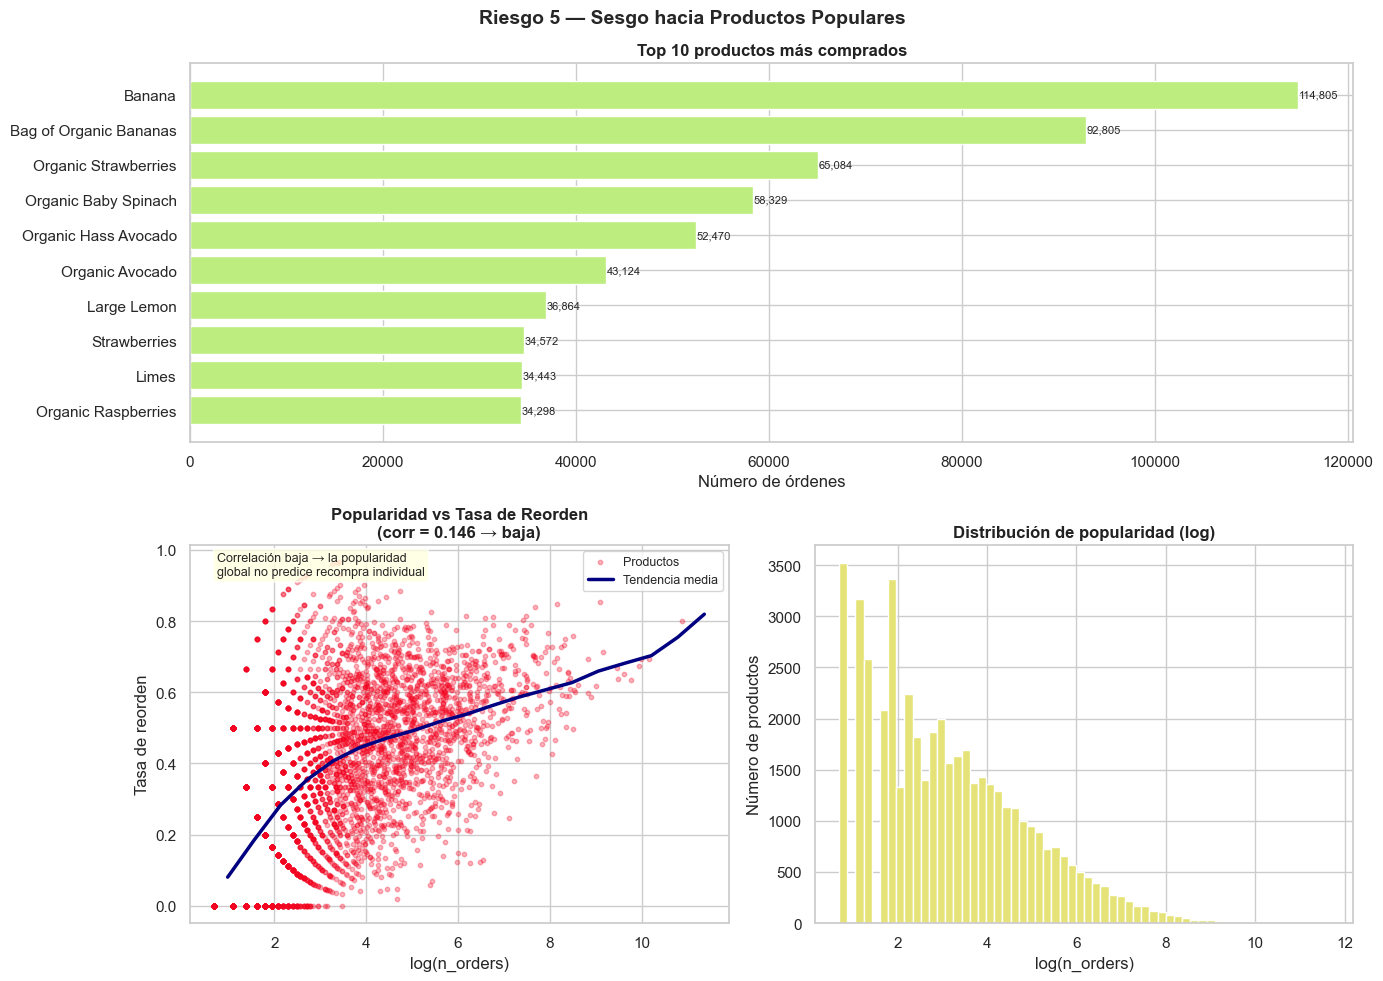

In [8]:
prod_popularity = (order_products_prior.groupby('product_id')
                   .agg(n_orders=('order_id', 'count'), reorder_rate=('reordered', 'mean'))
                   .reset_index())

percentiles   = [50, 75, 90, 95, 99]
pctile_values = np.percentile(prod_popularity['n_orders'], percentiles)

print('Concentración de popularidad:')
for p, v in zip(percentiles, pctile_values):
    print(f'  Percentil {p:2d}: {v:>8,.0f} órdenes')

top1_threshold = np.percentile(prod_popularity['n_orders'], 99)
top1_products  = prod_popularity[prod_popularity['n_orders'] >= top1_threshold]
top1_share     = top1_products['n_orders'].sum() / prod_popularity['n_orders'].sum()
corr = prod_popularity[['n_orders', 'reorder_rate']].corr().iloc[0, 1]

print(f'\nTop 1% de productos ({len(top1_products):,}) concentra el {top1_share:.1%} de las compras')
print(f'Correlación popularidad ↔ tasa de reorden: {corr:.3f}')

fig = plt.figure(figsize=(14, 10))
ax_top  = fig.add_subplot(2, 1, 1)
ax_scat = fig.add_subplot(2, 2, 3)
ax_hist = fig.add_subplot(2, 2, 4)

# ── Fila 1: Top 10 productos ───────────────────────────────
top10 = (prod_popularity
         .merge(products[['product_id', 'product_name']], on='product_id')
         .nlargest(10, 'n_orders')
         .sort_values('n_orders'))
top10['short_name'] = top10['product_name'].str[:30]

ax_top.barh(top10['short_name'], top10['n_orders'],
            color='#bded7e', edgecolor='white')
ax_top.set_title('Top 10 productos más comprados', fontweight='bold', fontsize=12)
ax_top.set_xlabel('Número de órdenes')
for i, v in enumerate(top10['n_orders']):
    ax_top.text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# ── Fila 2 izq: Scatter popularidad vs reorden ─────────────
prod_popularity['log_orders'] = np.log1p(prod_popularity['n_orders'])
bins = np.linspace(prod_popularity['log_orders'].min(), prod_popularity['log_orders'].max(), 20)
prod_popularity['bin'] = pd.cut(prod_popularity['log_orders'], bins=bins)
bin_stats   = prod_popularity.groupby('bin', observed=True)['reorder_rate'].mean()
bin_centers = [(i.left + i.right) / 2 for i in bin_stats.index]

sample_sc = prod_popularity.sample(min(5000, len(prod_popularity)), random_state=42)
ax_scat.scatter(np.log1p(sample_sc['n_orders']), sample_sc['reorder_rate'],
                alpha=0.3, s=10, color='#f30521', label='Productos')
ax_scat.plot(bin_centers, bin_stats.values,
             color='navy', linewidth=2.5, label='Tendencia media')
ax_scat.set_title(f'Popularidad vs Tasa de Reorden\n(corr = {corr:.3f} → baja)',
                  fontweight='bold', fontsize=12)
ax_scat.set_xlabel('log(n_orders)')
ax_scat.set_ylabel('Tasa de reorden')
ax_scat.legend(fontsize=9)
ax_scat.text(0.05, 0.92,
             'Correlación baja → la popularidad\nglobal no predice recompra individual',
             transform=ax_scat.transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Fila 2 der: Distribución de popularidad ────────────────
ax_hist.hist(prod_popularity['log_orders'], bins=60,
             color='#e5e377', edgecolor='white')
ax_hist.set_title('Distribución de popularidad (log)', fontweight='bold', fontsize=12)
ax_hist.set_xlabel('log(n_orders)')
ax_hist.set_ylabel('Número de productos')

plt.suptitle('Riesgo 5 — Sesgo hacia Productos Populares',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'q5_sesgo_popularidad_v2.png', bbox_inches='tight')
plt.show()

prod_popularity.drop(columns=['log_orders', 'bin'], inplace=True)

quality_report['sesgo_popularidad'] = {
    'top1_share_compras': round(float(top1_share), 4),
    'percentiles': dict(zip([f'p{p}' for p in percentiles], [int(v) for v in pctile_values])),
    'corr_popularidad_reorder': round(float(corr), 4)
}

### **Hallazgo clave** — Correlación popularidad ↔ tasa de reorden

> 🔍 **La correlación entre popularidad global y tasa de reorden
> es baja.** Esto significa que un producto muy comprado por la
> comunidad no necesariamente es un producto que un usuario específico
> vaya a recomprar.
>
> **Implicancia directa para el modelo:** las features de popularidad
> global (`product_total_purchases`, `product_reorder_rate`) tienen
> valor como señal de referencia, pero **no son suficientes** por sí
> solas. Las features de interacción usuario × producto
> (`up_times_purchased`, `up_reorder_rate`) son las que capturan
> la señal personalizada que distingue a LightGBM de un baseline
> de popularidad.
>
> Si la correlación fuera alta (> 0.6), el baseline de popularidad
> global sería difícil de superar. Una correlación baja es una buena
> noticia — justifica el esfuerzo de construir un modelo personalizado.

---
## Sección 7 — Reporte consolidado y exportación

Genera la tabla resumen de los 5 riesgos con severidad y acciones sugeridas,
y exporta a **CSV** y **HTML**.

In [9]:
summary_rows = [
    {
        'Riesgo': 'Desbalance de clases',
        'Métrica': f'Ratio 0:1 = {quality_report["desbalance_clases"]["ratio_0_1"]}',
        'Severidad': quality_report['desbalance_clases']['severidad'],
        'Acción sugerida': 'class_weight / scale_pos_weight en el modelo'
    },
    {
        'Riesgo': 'Alta cardinalidad',
        'Métrica': f'{quality_report["alta_cardinalidad"]["n_productos_total"]:,} productos',
        'Severidad': 'ALTA',
        'Acción sugerida': 'Filtrar productos con < 50 apariciones para el MVP'
    },
    {
        'Riesgo': 'Sparsity de usuarios',
        'Métrica': f'Sparsity media = {quality_report["sparsity_usuarios"]["sparsity_media_matriz"]:.4%}',
        'Severidad': 'ALTA',
        'Acción sugerida': 'Filtrar usuarios con < 5 órdenes / popularidad como fallback'
    },
    {
        'Riesgo': 'Data leakage temporal',
        'Métrica': f'Resultado: {quality_report["leakage_temporal"]["resultado_global"]}',
        'Severidad': 'OK' if quality_report['leakage_temporal']['resultado_global'] == 'OK' else 'CRÍTICO',
        'Acción sugerida': 'Estructura prior/train/test respetada ✅' if quality_report['leakage_temporal']['resultado_global'] == 'OK' else 'Revisar split temporal'
    },
    {
        'Riesgo': 'Sesgo hacia productos populares',
        'Métrica': f'Top 1% = {quality_report["sesgo_popularidad"]["top1_share_compras"]:.1%} compras',
        'Severidad': 'MEDIA',
        'Acción sugerida': 'Incluir features de popularidad relativa al usuario'
    }
]

df_summary = pd.DataFrame(summary_rows)

def color_severity(val):
    colors = {'CRÍTICO': 'background-color:#ff4444;color:white',
              'ALTA':    'background-color:#ff9944;color:white',
              'MEDIA':   'background-color:#ffdd44',
              'BAJA':    'background-color:#88cc44',
              'OK':      'background-color:#44bb44;color:white'}
    return colors.get(val, '')

display(df_summary.style.applymap(color_severity, subset=['Severidad']))

,Riesgo,Métrica,Severidad,Acción sugerida
0,Desbalance de clases,Ratio 0:1 = 0.69,BAJA,class_weight / scale_pos_weight en el modelo
1,Alta cardinalidad,"49,688 productos",ALTA,Filtrar productos con < 50 apariciones para el MVP
2,Sparsity de usuarios,Sparsity media = 99.8692%,ALTA,Filtrar usuarios con < 5 órdenes / popularidad como fallback
3,Data leakage temporal,Resultado: OK,OK,Estructura prior/train/test respetada ✅
4,Sesgo hacia productos populares,Top 1% = 41.9% compras,MEDIA,Incluir features de popularidad relativa al usuario


In [10]:
# ── Exportar CSV ──────────────────────────────────────────
csv_path = OUTPUT_PATH / 'reporte_calidad_datos.csv'
df_summary.to_csv(csv_path, index=False)
print(f'✅ CSV: {csv_path}')

# ── Exportar HTML ──────────────────────────────────────────
html_path = OUTPUT_PATH / 'reporte_calidad_datos.html'
modo_str  = f'MVP ({N_USUARIOS:,} usuarios)' if MVP_MODE else 'Dataset completo'

html_content = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <title>Reporte de Calidad – Insight Commerce</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 40px; background: #f5f5f5; }}
    h1   {{ color: #222; border-bottom: 3px solid #f5c400; padding-bottom: 8px; }}
    h2   {{ color: #444; margin-top: 30px; }}
    table {{ border-collapse: collapse; width: 100%; background: white;
             box-shadow: 0 2px 6px rgba(0,0,0,.1); }}
    th   {{ background: #222; color: white; padding: 12px; text-align: left; }}
    td   {{ padding: 10px 12px; border-bottom: 1px solid #eee; }}
    .ALTA    {{ background:#ff9944; color:white; font-weight:bold; border-radius:4px; padding:3px 8px; }}
    .CRITICO {{ background:#ff4444; color:white; font-weight:bold; border-radius:4px; padding:3px 8px; }}
    .MEDIA   {{ background:#ffdd44; font-weight:bold; border-radius:4px; padding:3px 8px; }}
    .OK      {{ background:#44bb44; color:white; font-weight:bold; border-radius:4px; padding:3px 8px; }}
    img  {{ max-width:100%; margin:15px 0; border-radius:8px; box-shadow:0 2px 8px rgba(0,0,0,.15); }}
    .meta {{ color:#666; font-size:.9em; margin-bottom:30px; }}
  </style>
</head>
<body>
  <h1>🔍 Reporte de Calidad – Insight Commerce</h1>
  <p class="meta">
    Dataset: Instacart Online Grocery &nbsp;|&nbsp;
    Modo: {modo_str} &nbsp;|&nbsp;
    Generado: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}
  </p>
  <h2>Resumen ejecutivo</h2>
  <table>
    <tr><th>Riesgo</th><th>Métrica clave</th><th>Severidad</th><th>Acción sugerida</th></tr>
"""
for _, row in df_summary.iterrows():
    sev = row['Severidad'].replace(' ', '_')
    html_content += f"""
    <tr>
      <td><strong>{row['Riesgo']}</strong></td>
      <td>{row['Métrica']}</td>
      <td><span class="{sev}">{row['Severidad']}</span></td>
      <td>{row['Acción sugerida']}</td>
    </tr>"""

html_content += """
  </table>
  <h2>Visualizaciones</h2>
  <h3>Riesgo 1 – Desbalance de clases</h3><img src="figures/q1_desbalance_clases.png">
  <h3>Riesgo 2 – Alta cardinalidad</h3><img src="figures/q2_alta_cardinalidad.png">
  <h3>Riesgo 3 – Sparsity de usuarios</h3><img src="figures/q3_sparsity_usuarios.png">
  <h3>Riesgo 4 – Leakage temporal</h3><img src="figures/q4_leakage_temporal.png">
  <h3>Riesgo 5 – Sesgo de popularidad</h3><img src="figures/q5_sesgo_popularidad.png">
</body></html>"""

with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f'✅ HTML: {html_path}')
print(f'\nArchivos en {OUTPUT_PATH}:')
for p in sorted(OUTPUT_PATH.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(OUTPUT_PATH)}')

✅ CSV: ../reports/reporte_calidad_datos.csv
✅ HTML: ../reports/reporte_calidad_datos.html

Archivos en ../reports:
  figures/q1_desbalance_clases.png
  figures/q2_alta_cardinalidad.png
  figures/q4_leakage_temporal.png
  figures/q5_sesgo_popularidad_v2.png
  git.keep
  logs/data_ingestation.log
  logs/data_loader.log
  logs/data_loader_local.log
  logs/dimensional_etl.log
  logs/feature_engineering.log
  logs/populate_dim_user.log
  logs/preprocessing.log
  reporte_calidad_datos.csv
  reporte_calidad_datos.html
